# Step-1:Data Collection

In [1]:
print("TOP OF FILE EXECUTED")

TOP OF FILE EXECUTED


In [2]:
!pip install google-cloud-storage

  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
Using cached rsa-4.9.1-py3-none-any.whl (34 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [google-cloud-storage]m 8/9 [google-cloud-storage]


### Downloading data from google cloud storage

In [3]:
from google.cloud import storage
import os
from time import sleep

#  Create anonymous GCS client
client = storage.Client.create_anonymous_client()
bucket = client.bucket("clusterdata-2011-2")

#  Folder to save files locally
save_dir = r"D:\google_cluster_trace\task_usage"
os.makedirs(save_dir, exist_ok=True)

#  Loop over all 500 files
for i in range(500):
    blob_name = f"task_usage/part-{i:05d}-of-00500.csv.gz"
    dest_file = os.path.join(save_dir, os.path.basename(blob_name))
    blob = bucket.blob(blob_name)

    #  Skip already downloaded files
    if os.path.exists(dest_file):
        print(f" [{i+1:03d}/500] Already exists → {os.path.basename(dest_file)}")
        continue

    print(f"  [{i+1:03d}/500] Downloading → {os.path.basename(blob_name)}")
    try:
        blob.download_to_filename(dest_file)
        print(f" [{i+1:03d}/500] Download complete → {os.path.basename(dest_file)}")
    except Exception as e:
        print(f" [{i+1:03d}/500] Failed: {os.path.basename(blob_name)} | Error: {e}")
        sleep(2)

print("\n All downloads finished! Check folder:")
print(save_dir)

  [001/500] Downloading → part-00000-of-00500.csv.gz
 [001/500] Download complete → part-00000-of-00500.csv.gz
  [002/500] Downloading → part-00001-of-00500.csv.gz
 [002/500] Download complete → part-00001-of-00500.csv.gz
  [003/500] Downloading → part-00002-of-00500.csv.gz
 [003/500] Download complete → part-00002-of-00500.csv.gz
  [004/500] Downloading → part-00003-of-00500.csv.gz
 [004/500] Download complete → part-00003-of-00500.csv.gz
  [005/500] Downloading → part-00004-of-00500.csv.gz
 [005/500] Download complete → part-00004-of-00500.csv.gz
  [006/500] Downloading → part-00005-of-00500.csv.gz
 [006/500] Download complete → part-00005-of-00500.csv.gz
  [007/500] Downloading → part-00006-of-00500.csv.gz
 [007/500] Download complete → part-00006-of-00500.csv.gz
  [008/500] Downloading → part-00007-of-00500.csv.gz
 [008/500] Download complete → part-00007-of-00500.csv.gz
  [009/500] Downloading → part-00008-of-00500.csv.gz
 [009/500] Download complete → part-00008-of-00500.csv.gz
 

# Data PreProcessing
### Merging all 500 files

In [1]:
import pandas as pd
import os
import glob

# -------------------------------
# 1️⃣ Define Paths
# -------------------------------

folder = r"D:\google_cluster_trace\task_usage"
output_file = r"D:\google_cluster_trace\task_usage_first8_merged.csv.gz"

# Get all .csv.gz files
files = sorted(glob.glob(os.path.join(folder, "*.csv.gz")))

print(f"Total files found: {len(files)}")

# -------------------------------
# 2️⃣ Merge Files (Chunk Based)
# -------------------------------

first = True  # Write header only once

for file_index, file in enumerate(files, start=1):
    
    print(f"[{file_index}/{len(files)}] Processing: {os.path.basename(file)}")
    
    # Read file in chunks to prevent memory overflow
    for chunk in pd.read_csv(
        file,
        compression='gzip',
        header=None,
        chunksize=500000
    ):
        
        # Keep only first 8 columns
        chunk = chunk.iloc[:, :8]
        
        # Remove completely empty rows (optional safety)
        chunk = chunk.dropna(how='all')
        
        # Append to output file
        chunk.to_csv(
            output_file,
            mode='a',
            index=False,
            header=first,
            compression='gzip'
        )
        
        first = False

print("\n✅ Merged dataset with first 8 columns created successfully.")
print(f"📁 Saved at: {output_file}")

Total files found: 499
[1/499] Processing: part-00001-of-00500.csv.gz
[2/499] Processing: part-00002-of-00500.csv.gz
[3/499] Processing: part-00003-of-00500.csv.gz
[4/499] Processing: part-00004-of-00500.csv.gz
[5/499] Processing: part-00005-of-00500.csv.gz
[6/499] Processing: part-00006-of-00500.csv.gz
[7/499] Processing: part-00007-of-00500.csv.gz
[8/499] Processing: part-00008-of-00500.csv.gz
[9/499] Processing: part-00009-of-00500.csv.gz
[10/499] Processing: part-00010-of-00500.csv.gz
[11/499] Processing: part-00011-of-00500.csv.gz
[12/499] Processing: part-00012-of-00500.csv.gz
[13/499] Processing: part-00013-of-00500.csv.gz
[14/499] Processing: part-00014-of-00500.csv.gz
[15/499] Processing: part-00015-of-00500.csv.gz
[16/499] Processing: part-00016-of-00500.csv.gz
[17/499] Processing: part-00017-of-00500.csv.gz
[18/499] Processing: part-00018-of-00500.csv.gz
[19/499] Processing: part-00019-of-00500.csv.gz
[20/499] Processing: part-00020-of-00500.csv.gz
[21/499] Processing: part-

In [3]:
final_df.head()

,window,task_count,avg_cpu,avg_memory
0,5400000000,980,0.003124,0.001424
1,5700000000,6355,0.014435,0.009479
2,6000000000,138715,0.015851,0.019560
3,6300000000,142034,0.014716,0.019120
4,6600000000,137543,0.014917,0.019690



### Machine-Wise 5min Aggregation

In [5]:
import pandas as pd
import numpy as np

input_file = r"D:\google_cluster_trace\task_usage_first8_merged.csv.gz"
output_file = r"D:\google_cluster_trace\machine_5min.csv"  # cleaner name

CHUNK_SIZE = 500000
WINDOW = 5 * 60 * 1_000_000  # 5 minutes in microseconds

# Correct column indexes
END_TIME_COL = 1
MACHINE_ID_COL = 4   # ✅ FIXED
CPU_COL = 5
MEM_COL = 6

agg_dict = {}

chunk_number = 0

for chunk in pd.read_csv(input_file, compression='gzip', chunksize=CHUNK_SIZE):

    chunk_number += 1
    print(f"Processing chunk {chunk_number}")

    end_time = chunk.iloc[:, END_TIME_COL]
    machine_id = chunk.iloc[:, MACHINE_ID_COL]
    cpu = chunk.iloc[:, CPU_COL]
    memory = chunk.iloc[:, MEM_COL]

    window = (end_time // WINDOW) * WINDOW

    for w, mid, c, m in zip(window, machine_id, cpu, memory):

        key = (w, mid)

        if key not in agg_dict:
            # [task_count, cpu_sum, mem_sum]
            agg_dict[key] = [0, 0.0, 0.0]

        agg_dict[key][0] += 1
        agg_dict[key][1] += c
        agg_dict[key][2] += m


# Convert dictionary to DataFrame
rows = []

for (w, mid), values in agg_dict.items():
    count, cpu_sum, mem_sum = values
    rows.append([
        w,
        mid,
        count,
        cpu_sum / count,
        mem_sum / count
    ])

final_df = pd.DataFrame(
    rows,
    columns=["window", "machine_id", "task_count", "avg_cpu", "avg_memory"]
)

final_df.sort_values(["window", "machine_id"], inplace=True)

final_df.to_csv(output_file, index=False)

print("✅ Machine-wise 5-min aggregation saved.")

Processing chunk 1
Processing chunk 2
Processing chunk 3
Processing chunk 4
Processing chunk 5
Processing chunk 6
Processing chunk 7
Processing chunk 8
Processing chunk 9
Processing chunk 10
Processing chunk 11
Processing chunk 12
Processing chunk 13
Processing chunk 14
Processing chunk 15
Processing chunk 16
Processing chunk 17
Processing chunk 18
Processing chunk 19
Processing chunk 20
Processing chunk 21
Processing chunk 22
Processing chunk 23
Processing chunk 24
Processing chunk 25
Processing chunk 26
Processing chunk 27
Processing chunk 28
Processing chunk 29
Processing chunk 30
Processing chunk 31
Processing chunk 32
Processing chunk 33
Processing chunk 34
Processing chunk 35
Processing chunk 36
Processing chunk 37
Processing chunk 38
Processing chunk 39
Processing chunk 40
Processing chunk 41
Processing chunk 42
Processing chunk 43
Processing chunk 44
Processing chunk 45
Processing chunk 46
Processing chunk 47
Processing chunk 48
Processing chunk 49
Processing chunk 50
Processin

### Download Machine Events Table

In [1]:
from google.cloud import storage
import os

client = storage.Client.create_anonymous_client()
bucket = client.bucket("clusterdata-2011-2")

save_dir = r"D:\google_cluster_trace\machine_events"
os.makedirs(save_dir, exist_ok=True)

blob_name = "machine_events/part-00000-of-00001.csv.gz"
dest_file = os.path.join(save_dir, os.path.basename(blob_name))

blob = bucket.blob(blob_name)

if not os.path.exists(dest_file):
    print("Downloading machine_events...")
    blob.download_to_filename(dest_file)
    print("Download complete!")
else:
    print("File already exists.")

Download complete!


### Preprocessing Machine Events Table

In [3]:
import os

os.getcwd()

'/Users/madhusudhan/google_data_centre'

In [4]:
os.listdir()

['D:\\google_cluster_trace\\machine_5min.csv',
 '.DS_Store',
 'D:\\google_cluster_trace\\task_usage',
 'Untitled.ipynb',
 'D:\\google_cluster_trace\\task_usage_first8_merged.csv.gz',
 'D:\\google_cluster_trace\\task_usage_5min_aggregated.csv',
 '.ipynb_checkpoints',
 'D:\\google_cluster_trace\\machine_events']

In [5]:
import os

print(os.path.isdir("D:\\google_cluster_trace\\machine_events"))
print(os.path.isfile("D:\\google_cluster_trace\\machine_events"))

True
False


In [6]:
os.listdir("D:\\google_cluster_trace\\machine_events")

['part-00000-of-00001.csv.gz', 'part-00000-of-00001.csv']

In [8]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if "part-00000" in f:
            print(os.path.join(root, f))

./D:\google_cluster_trace\task_usage/part-00000-of-00500.csv
./D:\google_cluster_trace\machine_events/part-00000-of-00001.csv.gz
./D:\google_cluster_trace\machine_events/part-00000-of-00001.csv


In [10]:
import pandas as pd

file = "./D:\\google_cluster_trace\\machine_events/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, nrows=1000)

df.columns = [
    "timestamp",
    "machine_id",
    "event_type",
    "platform_id",
    "cpu_capacity",
    "memory_capacity"
]

df

,timestamp,machine_id,event_type,platform_id,cpu_capacity,memory_capacity
0,0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
1,0,6,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
2,0,7,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
3,0,10,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
4,0,13,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
...,...,...,...,...,...,...
995,0,908061,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.4995
996,0,908063,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.4995
997,0,908177,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.4995
998,0,908184,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.4995


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        1000 non-null   int64  
 1   machine_id       1000 non-null   int64  
 2   event_type       1000 non-null   int64  
 3   platform_id      1000 non-null   object 
 4   cpu_capacity     1000 non-null   float64
 5   memory_capacity  1000 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 47.0+ KB


In [12]:
df['event_type'].value_counts()

event_type
0    1000
Name: count, dtype: int64

In [13]:
df['machine_id'].nunique()
df['machine_id'].head()

0     5
1     6
2     7
3    10
4    13
Name: machine_id, dtype: int64

In [14]:
df['platform_id'].nunique()
df['platform_id'].value_counts().head()

platform_id
HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=    1000
Name: count, dtype: int64

In [15]:
df['timestamp'].min()
df['timestamp'].max()

0

In [16]:
df['event_type'].unique()

array([0])

In [17]:
df['event_type'].nunique()

1

In [18]:
df['event_type'].value_counts()

event_type
0    1000
Name: count, dtype: int64

### Creating Machine wise CSV files

In [2]:
import pandas as pd
import os

# Load the saved aggregated file
final_df = pd.read_csv(r"D:\google_cluster_trace\machine_5min.csv")

# Now split
output_dir = r"D:\google_cluster_trace\machines_csv"
os.makedirs(output_dir, exist_ok=True)

for machine_id, group in final_df.groupby("machine_id"):
    file_path = os.path.join(output_dir, f"machine_{int(machine_id)}.csv")
    group.to_csv(file_path, index=False)

print("✅ CSV files created.")

✅ CSV files created.


### Downloading Machine Attributes Table

In [3]:
from google.cloud import storage
import os

client = storage.Client.create_anonymous_client()
bucket = client.bucket("clusterdata-2011-2")

save_dir = r"D:\google_cluster_trace\machine_attributes"
os.makedirs(save_dir, exist_ok=True)

blob_name = "machine_attributes/part-00000-of-00001.csv.gz"
dest_file = os.path.join(save_dir, os.path.basename(blob_name))

blob = bucket.blob(blob_name)

if not os.path.exists(dest_file):
    print("Downloading machine_attributes...")
    blob.download_to_filename(dest_file)
    print("Download complete!")
else:
    print("File already exists.")

Download complete!


In [5]:
from google.cloud import storage
import os

client = storage.Client.create_anonymous_client()
bucket = client.bucket("clusterdata-2011-2")

save_dir = r"D:\google_cluster_trace\machine_attributes"
os.makedirs(save_dir, exist_ok=True)

blobs = client.list_blobs(bucket, prefix="machine_attributes/")

for blob in blobs:
    if blob.name.endswith(".csv.gz"):
        dest_file = os.path.join(save_dir, os.path.basename(blob.name))
        
        if not os.path.exists(dest_file):
            print(f"Downloading {blob.name}...")
            blob.download_to_filename(dest_file)

print("✅ All files downloaded.")

✅ All files downloaded.


### Analyze Machine Attribute Table

In [7]:
import os

dir_path = r"D:\google_cluster_trace\machine_attributes"
files = os.listdir(dir_path)

print(files)

['.DS_Store', 'part-00000-of-00001.csv.gz', 'part-00000-of-00001.csv']


In [10]:
import os
print(os.getcwd())

/Users/madhusudhan/google_data_centre


In [11]:
import os

print(os.listdir())

['D:\\google_cluster_trace\\machine_attributes', 'D:\\google_cluster_trace\\machine_5min.csv.zip', 'D:\\google_cluster_trace\\machine_5min.csv', '.DS_Store', 'D:\\google_cluster_trace\\task_usage', 'Untitled.ipynb', 'D:\\google_cluster_trace\\machines_csv', 'D:\\google_cluster_trace\\task_usage_first8_merged.csv.gz', 'D:\\google_cluster_trace\\task_usage_5min_aggregated.csv', '.ipynb_checkpoints', 'D:\\google_cluster_trace\\machine_events']


In [12]:
import os

folder = "D:\\google_cluster_trace\\machine_attributes"
print(os.listdir(folder))

['.DS_Store', 'part-00000-of-00001.csv.gz', 'part-00000-of-00001.csv']


In [14]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[2, 3])
df.columns = ["attribute_name", "attribute_value"]

print(df.head())
print(df.groupby("attribute_name")["attribute_value"].nunique())

                                 attribute_name attribute_value
0  +8aLrMrUBQLYLD4Ndxi/ZmwwKGhtFGskL8ZSdChYMdo=               1
1  4chZqkETND7f4XrzdWLe8c1eLHKuYgjnUMSV+83EYFA=               1
2  5dEuieuWMFy+CNMBBf/uXNX5nP4Kgzeu0O6UizRNK3w=               2
3  81Cd14q4ebyI/3TPkkIwGYlB/mvKhBUk3e/E8egb4s0=               2
4  9eCGRtl6XN5GQoOYGEjKtupBbtUoOaOPYRFw+pzH7IU=               2
attribute_name
+8aLrMrUBQLYLD4Ndxi/ZmwwKGhtFGskL8ZSdChYMdo=      1
0xo576GO0NtrJrOsohXyU1rcY2xvi5Tvbus9zY1AzJI=      1
3CusDtw4S6+y7vNAxt3TErcLThHzyAXmG7n18SwY1KM=      1
4chZqkETND7f4XrzdWLe8c1eLHKuYgjnUMSV+83EYFA=      1
5A/UHgbeJPGWK0VQpMLoGVRejsVhhFE57cBUjlOo6gI=      1
                                               ... 
w3/Je6spb3dt6QfX5PwD2MXqxLTzNur/Ts5JrAwl8xQ=     11
wNqCDsckjGmkiJStuw+dRMj7oqxTnYssARjPB96ws4Y=      1
xrLPEfaLoWqEPusv42iPso8MZvlF92N/A3o5pR/IMCQ=    406
zeTYeXds5XbzYVzUiHe9t3y9K3L5vndxaOFW8btTjU4=      1
zqEOkdzktGuy9oI7M6oIKxqbyfanRB/pf+3HPNLTSqg=      1
Name: attribute_value, Length

In [15]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[2])
df.columns = ["attribute_name"]

# count frequency of each attribute_name
counts = df["attribute_name"].value_counts()

print(counts)

attribute_name
p8ZhzZo6jUe5PdjVklNuNCkogJqCEFA33ZThAAVyqWg=    10128730
s93lk/yiSwQSBKWr6vfu+qa9xSjEKfQVkl1SEyn3Kow=       39412
ZpZw+sjJYrnkTFaQa7zK5u8CazfWK8wK8NP496eDlRA=       26908
81Cd14q4ebyI/3TPkkIwGYlB/mvKhBUk3e/E8egb4s0=       26050
iDmVM9CBJbfsTpobqwGRQiSXP2hcCJYwMpY68x9ri9w=       25234
                                                  ...   
BwF2Hf0IniEL56N9HUmYrefppYb5OLBxuu7u1yGOlmo=         316
7obfDY3pItdzskpDqnOvi+oCNJ4lIhlSi42bN7rrK48=         316
o/0PSEOQ9jWyzNMXehU3dXqePQIE2QxyxyknZMT1k4c=         145
LKvQbl09pG8btYiBYJWd+pTltGRFZoUHppRdmZqK0EI=          47
StKUa3Jpf/WqqtUVvj209AVGVQDdyOFFKA0yOKzyFUQ=          16
Name: count, Length: 67, dtype: int64


In [16]:
print(counts.head(10))

attribute_name
p8ZhzZo6jUe5PdjVklNuNCkogJqCEFA33ZThAAVyqWg=    10128730
s93lk/yiSwQSBKWr6vfu+qa9xSjEKfQVkl1SEyn3Kow=       39412
ZpZw+sjJYrnkTFaQa7zK5u8CazfWK8wK8NP496eDlRA=       26908
81Cd14q4ebyI/3TPkkIwGYlB/mvKhBUk3e/E8egb4s0=       26050
iDmVM9CBJbfsTpobqwGRQiSXP2hcCJYwMpY68x9ri9w=       25234
qtu6+42tn0xPmcv0ODnGWRQM0J/SgMM9lNsxc3ckbLw=       25234
QlHb0NMTSytpaiRqXo9rzLE+wu5f7Cx4uvIm3KZc8lQ=       20237
Eqr5/diyFWeYBfm508mvBV9y9L8uPjCkYuL1DtgDaSU=       16364
Mq8KjADLLByyElVUq+c3cFVdXgFEfeCJhw+fKPgWjI4=       13121
xrLPEfaLoWqEPusv42iPso8MZvlF92N/A3o5pR/IMCQ=       12743
Name: count, dtype: int64


In [17]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[3])
df.columns = ["attribute_value"]

counts = df["attribute_value"].value_counts()

print(counts)

attribute_value
JXB8WHrJgrUmOCO/cAJjldoh/Eo0jgIdCxVtOloO5tM=    2474465
3oaOYSSGfifrdnzKYoZlEDtBBzl7ErG8fqUB72jVxv4=    1885973
lYF9VCoTJ5FptkBHihIMHZsZKdDKPD3eShXvHLE1aww=     700853
9oFWNR7N2j1/NxwsrCFfim2rFZL9bjUe6ZZ5vBeii6U=     612816
+sJ69cS7gOT30Ow4o5i54UqaO8Tam4SUHVCbw03mad4=     518042
                                                 ...   
IY3tMXAwZV4myqk2AUtxuL3ZLMl44oZgou4tj16thDA=          1
sj9IRUZZkl5pBa8Hc4609bY+9Wg35v4n2Wrmxvrh/xg=          1
0tEf6j8cf258wtb2XQ8UFS2vemocQPTDuhibeosDqvo=          1
B5ziOZm9dJ8KKfzmbb80DhbJ8810ckNkzJx+5N/qFqU=          1
xzSoQS6GOb5SGS+ph0q9sIh4xFMEd20jjycR1CPwzaE=          1
Name: count, Length: 18011, dtype: int64


In [19]:
print(counts.head(20))

attribute_value
JXB8WHrJgrUmOCO/cAJjldoh/Eo0jgIdCxVtOloO5tM=    2474465
3oaOYSSGfifrdnzKYoZlEDtBBzl7ErG8fqUB72jVxv4=    1885973
lYF9VCoTJ5FptkBHihIMHZsZKdDKPD3eShXvHLE1aww=     700853
9oFWNR7N2j1/NxwsrCFfim2rFZL9bjUe6ZZ5vBeii6U=     612816
+sJ69cS7gOT30Ow4o5i54UqaO8Tam4SUHVCbw03mad4=     518042
b+Sjybrui7jhbh/hi6kOVfaelY75LgkYP9AxCMGN0VA=     454076
Hl8XVh9Ozi5VOW8HW3sSkocN2O3qqHtohBQ6TolnXzo=     358835
rYdZofFoBzYtwLRHXUVSUL9KhmgQ/g0QEuNGCri56N4=     327208
1                                                204935
FFCM2qj5F8MmdBgcvfyvhY2izv88oXp4vOWmXw3Zseg=     194331
dQcbIhtluu0kDC8Ut+4RCMukzfihw8TcIrVXk7TKC00=     193077
c3jCizIkz+WvNJ3AaoJ6mIKeDSync0TDEkB5x8moGg0=     191883
71kVpbt2ly23rAH/I+c3HmJ1Bkm0cn4zm9OUB6QLgr0=     169891
UT28J9YCXk/PpSnr4kBZ1Mb/a2S2MbXD3xwGEl1Plfs=     163915
gSNxyfoEyBq74AJ5rUhIufzbf/7bCV1fe73F5Ibn2Ns=     143093
Bfd8jT1rOqs9aBXEDMkEiHy2LxlKM2QgE2+HJpHuwi0=     119927
2                                                114969
vmK5K8PKF01UcHv9OcoyHVnnoDVu1XYh

In [20]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[1])
df.columns = ["machine_id"]

print(df["machine_id"].nunique())

12583


In [21]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[2])
df.columns = ["attribute_name"]

print(df["attribute_name"].nunique())

67


In [23]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[1,2])
df.columns = ["machine_id", "attribute_name"]

counts = df.groupby("machine_id")["attribute_name"].nunique()

print(counts.describe())

count    12583.000000
mean        42.918302
std          2.399001
min         40.000000
25%         42.000000
50%         42.000000
75%         43.000000
max         53.000000
Name: attribute_name, dtype: float64


In [24]:
duplicates = df.duplicated(subset=["machine_id", "attribute_name"])

print("Duplicate rows exist:", duplicates.any())

Duplicate rows exist: True


In [25]:
dup_rows = df[df.duplicated(subset=["machine_id", "attribute_name"], keep=False)]

print(dup_rows.head())

    machine_id                                attribute_name
3            5  81Cd14q4ebyI/3TPkkIwGYlB/mvKhBUk3e/E8egb4s0=
23           5  ZpZw+sjJYrnkTFaQa7zK5u8CazfWK8wK8NP496eDlRA=
26           5  iDmVM9CBJbfsTpobqwGRQiSXP2hcCJYwMpY68x9ri9w=
33           5  p8ZhzZo6jUe5PdjVklNuNCkogJqCEFA33ZThAAVyqWg=
34           5  qtu6+42tn0xPmcv0ODnGWRQM0J/SgMM9lNsxc3ckbLw=


In [26]:
counts = df.groupby("machine_id")["attribute_name"].nunique()

print("Min attributes:", counts.min())
print("Max attributes:", counts.max())

Min attributes: 40
Max attributes: 53


In [29]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[0,1,2,3])
df.columns = ["timestamp", "machine_id", "attribute_name", "attribute_value"]

In [ ]:
dup_rows = df[df.duplicated(subset=["machine_id", "attribute_name"], keep=False)]

print(dup_rows.head(50))

In [32]:
import pandas as pd

file = "D:\\google_cluster_trace\\machine_attributes/part-00000-of-00001.csv"

df = pd.read_csv(file, header=None, usecols=[3])
df.columns = ["attribute_value"]

print(df["attribute_value"].nunique())

18011


### Converting Machines to Clients

In [3]:
import os

input_dir = r"D:\google_cluster_trace\machines_csv"

files = os.listdir(input_dir)

# extract machine ids from filenames
machine_ids = [int(f.split("_")[1].split(".")[0]) for f in files]

In [4]:
import random

random.shuffle(machine_ids)

In [5]:
n_clients = 50

clusters = []
size = len(machine_ids) // n_clients

for i in range(n_clients):
    start = i * size
    end = (i + 1) * size if i != n_clients - 1 else len(machine_ids)
    clusters.append(machine_ids[start:end])

In [6]:
import json

cluster_dict = {f"client_{i}": clusters[i] for i in range(n_clients)}

with open("clusters.json", "w") as f:
    json.dump(cluster_dict, f)

print("✅ Random clusters created")

✅ Random clusters created


In [7]:
output_base = r"D:\google_cluster_trace\clients"

os.makedirs(output_base, exist_ok=True)

for i, machine_list in enumerate(clusters):
    client_dir = os.path.join(output_base, f"client_{i}")
    os.makedirs(client_dir, exist_ok=True)

    for mid in machine_list:
        src = os.path.join(input_dir, f"machine_{mid}.csv")
        dst = os.path.join(client_dir, f"machine_{mid}.csv")
        
        if os.path.exists(src):
            import shutil
            shutil.copy(src, dst)

In [2]:
import os

input_dir = r"D:\google_cluster_trace\machines_csv"

files = [f for f in os.listdir(input_dir) if f.endswith(".csv")]

# extract machine ids
machine_ids = [int(f.split("_")[1].split(".")[0]) for f in files]

machine_ids.sort()

# 🔥 create 50 clusters
num_clients = 50
clusters = np.array_split(machine_ids, num_clients)

# convert to list of lists
clusters = [list(c) for c in clusters]

print(f"Total clusters created: {len(clusters)}")
print("Example cluster:", clusters[0])

Total clusters created: 50
Example cluster: [np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(13), np.int64(14), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(41), np.int64(43), np.int64(45), np.int64(46), np.int64(49), np.int64(52), np.int64(54), np.int64(56), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(67), np.int64(68), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(121306), np.int64(243096), np.int64(381113), np.int64(381126), np.int64(381128), np.int64(381129), np.int64(381133), np.int64(381139), np.int64(381227), np.int64(381233), np.int64(381234), np.int64(381235), np.int64(381236), np.int64(381352), np.int64(381361), np.int64(381364), np.int64(381365), np.int64(381368), np.int64(381369), np.int64(381370), np.int64(381371), np.int64(381374), np.int64(381378), np.int64(381381), np.int64(381384), np.int64(381386), 

### Client AVG

In [4]:
import os
import pandas as pd
import numpy as np

output_base = r"D:\google_cluster_trace\clients_avg"
os.makedirs(output_base, exist_ok=True)

for i, machine_list in enumerate(clusters):
    print(f"\nProcessing client {i} | machines: {len(machine_list)}")

    cpu_series_list = []
    mem_series_list = []

    max_len = 0

    # 🔥 LOAD DATA
    for mid in machine_list:
        file_path = os.path.join(input_dir, f"machine_{int(mid)}.csv")

        if not os.path.exists(file_path):
            continue

        try:
            df = pd.read_csv(file_path)

            # 🔍 find CPU & Memory columns
            cpu_cols = [c for c in df.columns if "cpu" in c.lower()]
            mem_cols = [c for c in df.columns if "mem" in c.lower()]

            if not cpu_cols or not mem_cols:
                continue

            cpu = df[cpu_cols[0]].values.astype(float)
            mem = df[mem_cols[0]].values.astype(float)

            cpu_series_list.append(cpu)
            mem_series_list.append(mem)

            max_len = max(max_len, len(cpu))

        except Exception as e:
            print(f"Error reading {mid}: {e}")

    if len(cpu_series_list) == 0:
        print(f"Client {i} skipped (no valid data)")
        continue

    # 🔥 PAD WITH NaN (to keep ALL rows)
    def pad_series(series_list, max_len):
        padded = []
        for s in series_list:
            if len(s) < max_len:
                pad = np.full(max_len - len(s), np.nan)
                s = np.concatenate([s, pad])
            padded.append(s)
        return np.array(padded)

    cpu_aligned = pad_series(cpu_series_list, max_len)
    mem_aligned = pad_series(mem_series_list, max_len)

    print(f"Aligned shape CPU: {cpu_aligned.shape}, MEM: {mem_aligned.shape}")

    # 🔥 AVERAGE (ignore NaN)
    avg_cpu = np.nanmean(cpu_aligned, axis=0)
    avg_mem = np.nanmean(mem_aligned, axis=0)

    # 🔥 SAVE
    out_df = pd.DataFrame({
        "time": np.arange(max_len),
        "cpu_usage": avg_cpu,
        "memory_usage": avg_mem
    })

    out_path = os.path.join(output_base, f"client_{i}.csv")
    out_df.to_csv(out_path, index=False)

    print(f"Saved client_{i}.csv | rows: {max_len}")


Processing client 0 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_0.csv | rows: 8337

Processing client 1 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_1.csv | rows: 8337

Processing client 2 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_2.csv | rows: 8337

Processing client 3 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_3.csv | rows: 8337

Processing client 4 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_4.csv | rows: 8337

Processing client 5 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_5.csv | rows: 8337

Processing client 6 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_6.csv | rows: 8337

Processing client 7 | machines: 252
Aligned shape CPU: (252, 8337), MEM: (252, 8337)
Saved client_7.csv | rows: 8337

Processing client 8 | machines: 252
Aligned shape CPU: 

In [2]:
# ================== IMPORTS ==================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random

### LSTM-Attention Model Architecture

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=10, hidden_size=128, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.attn = nn.Linear(hidden_size, 1)

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 2)  # 🔥 CPU + MEMORY

    def forward(self, x):
        out, _ = self.lstm(x)

        attn_weights = torch.softmax(self.attn(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)

        out = self.fc1(context)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out)

### Data Loading, Feature Engineering & Normalization

In [4]:
def load_split_normalize(file_path, window_size):
    df = pd.read_csv(file_path)

    cpu = df["cpu_usage"].values.astype(float)
    mem = df["memory_usage"].values.astype(float)

    df = pd.DataFrame({
        "cpu": cpu,
        "mem": mem
    })

    # CPU features
    df["cpu_diff"] = df["cpu"].diff()
    df["cpu_ma_3"] = df["cpu"].rolling(3).mean()
    df["cpu_std_3"] = df["cpu"].rolling(3).std()

    # Memory features
    df["mem_diff"] = df["mem"].diff()
    df["mem_ma_3"] = df["mem"].rolling(3).mean()
    df["mem_std_3"] = df["mem"].rolling(3).std()

    # Spikes
    df["cpu_spike"] = (df["cpu_diff"] > df["cpu_diff"].std()).astype(int)
    df["mem_spike"] = (df["mem_diff"] > df["mem_diff"].std()).astype(int)

    df = df.dropna().reset_index(drop=True)

    data = df.values  # 🔥 10 features

    if len(data) < window_size + 1:
        return None

    split = int(0.8 * len(data))
    train_data = data[:split]
    test_data = data[split:]

    mean = train_data.mean(axis=0)
    std = train_data.std(axis=0) + 1e-6

    train_data = (train_data - mean) / std
    test_data = (test_data - mean) / std

    return train_data, test_data, mean, std

### Sequence Generation for Time-Series Forecasting

In [5]:
def create_sequences(data, window_size):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size][:2])  # 🔥 CPU + MEMORY

    return np.array(X), np.array(y)

In [6]:
def compute_metrics(y_true, y_pred):
    y_pred = y_pred

    mse = np.mean((y_true - y_pred) ** 2, axis=0)
    mae = np.mean(np.abs(y_true - y_pred), axis=0)
    rmse = np.sqrt(mse)

    return mse, mae, rmse

### Local Client Model Training

In [7]:
def train_local(model, X, y, epochs=15, batch_size=32):
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    loss_fn = nn.HuberLoss(delta=1.0)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    total_loss, count = 0, 0

    for _ in range(epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            pred = model(batch_X)
            loss = loss_fn(pred, batch_y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * batch_X.size(0)
            count += batch_X.size(0)

    return model.state_dict(), total_loss / count

### Aquila Optimizer for Adaptive Weight Selection

In [8]:
def aquila_optimizer(losses, pop_size=10, iters=30):
    losses = np.array(losses)
    n = len(losses)

    # Normalize losses (important)
    losses = losses / (np.max(losses) + 1e-8)

    # Initialize population (valid probability vectors)
    pop = np.random.rand(pop_size, n)
    pop = pop / pop.sum(axis=1, keepdims=True)

    best = pop[0].copy()
    best_fit = float("inf")

    lambda_reg = 0.1  # regularization to avoid collapse

    for t in range(iters):

        for i in range(pop_size):
            alpha = pop[i]

            # Fitness function (minimize weighted loss + smoothness)
            fitness = np.sum(alpha * losses) + lambda_reg * np.sum(alpha**2)

            if fitness < best_fit:
                best_fit = fitness
                best = alpha.copy()

        # -------- Aquila Update Phases --------
        for i in range(pop_size):

            r1 = np.random.rand(n)
            r2 = np.random.rand(n)

            if t < iters / 2:
                # Exploration phase
                pop[i] = pop[i] + 0.5 * (r1 - r2)
            else:
                # Exploitation phase (move toward best)
                pop[i] = pop[i] + 0.5 * (best - pop[i]) + 0.1 * (r1 - r2)

            # Keep weights valid
            pop[i] = np.clip(pop[i], 1e-6, None)
            pop[i] = pop[i] / pop[i].sum()

    # Final smoothing (VERY IMPORTANT)
    temperature = 0.5
    best = np.exp(best / temperature)
    best = best / best.sum()

    return best

In [9]:
# ================== AGGREGATION ==================
def aggregate_aquila(global_model, local_weights, losses):
    alphas = aquila_optimizer(losses)
    print("Aquila Weights:", np.round(alphas, 3))

    new_weights = {}

    for key in global_model.state_dict().keys():
        new_weights[key] = sum(
            local_weights[i][key] * alphas[i]
            for i in range(len(local_weights))
        )

    global_model.load_state_dict(new_weights)
    return global_model


### Federated Learning 

In [10]:
def federated_training(base_path, rounds=5, window_size=30):

    client_files = [
        os.path.join(base_path, f)
        for f in os.listdir(base_path)
        if f.endswith(".csv")
    ]

    global_model = LSTMModel()

    # 🔥 FIX CLIENTS ONCE
    selected_clients = random.sample(client_files, min(5, len(client_files)))

    print("\nSelected Clients:")
    for c in selected_clients:
        print(os.path.basename(c))

    all_mse = []
    all_rmse = []
    client_predictions = {}

    for r in range(rounds):
        print(f"\n========== ROUND {r+1} ==========")

        local_weights = []
        losses = []
        round_mse = []
        round_rmse = []

        for file in selected_clients:   # 🔥 SAME CLIENTS EVERY ROUND

            result = load_split_normalize(file, window_size)
            if result is None:
                continue

            train_data, test_data, mean, std = result

            X_train, y_train = create_sequences(train_data, window_size)
            X_test, y_test = create_sequences(test_data, window_size)

            if len(X_train) == 0 or len(X_test) == 0:
                continue

            local_model = LSTMModel()
            local_model.load_state_dict(global_model.state_dict())

            weights, _ = train_local(local_model, X_train, y_train)

            local_model.eval()

            with torch.no_grad():
                preds = local_model(torch.tensor(X_test, dtype=torch.float32)).numpy()

            # 🔥 DENORMALIZE
            preds[:, 0] = preds[:, 0] * std[0] + mean[0]
            preds[:, 1] = preds[:, 1] * std[1] + mean[1]

            y_test[:, 0] = y_test[:, 0] * std[0] + mean[0]
            y_test[:, 1] = y_test[:, 1] * std[1] + mean[1]

            mse, mae, rmse = compute_metrics(y_test, preds)

            print(f"\n{os.path.basename(file)}")
            print(f"CPU → MSE:{mse[0]:.8f}, RMSE:{rmse[0]:.6f}")
            print(f"MEM → MSE:{mse[1]:.8f}, RMSE:{rmse[1]:.6f}")

            client_predictions[os.path.basename(file)] = {
                "y_true": y_test,
                "y_pred": preds
            }

            local_weights.append(weights)
            losses.append(np.mean(rmse))

            round_mse.append(np.mean(mse))
            round_rmse.append(np.mean(rmse))

        if not local_weights:
            continue

        avg_mse = np.mean(round_mse)
        avg_rmse = np.mean(round_rmse)

        print("\n===== ROUND AVG =====")
        print(f"MSE:{avg_mse:.8f}, RMSE:{avg_rmse:.6f}")

        all_mse.append(avg_mse)
        all_rmse.append(avg_rmse)

        global_model = aggregate_aquila(global_model, local_weights, losses)

    return global_model, all_mse, all_rmse, client_predictions

In [11]:
base_path = r"D:\google_cluster_trace\clients_avg"

model, mse_list, rmse_list, client_preds = federated_training(base_path)




Selected Clients:
client_2.csv
client_19.csv
client_12.csv
client_36.csv
client_39.csv

========== ROUND 1 ==========

client_2.csv
CPU → MSE:0.00000055, RMSE:0.000740
MEM → MSE:0.00000035, RMSE:0.000590

client_19.csv
CPU → MSE:0.00000127, RMSE:0.001128
MEM → MSE:0.00000085, RMSE:0.000924

client_12.csv
CPU → MSE:0.00000050, RMSE:0.000705
MEM → MSE:0.00000022, RMSE:0.000466

client_36.csv
CPU → MSE:0.00000054, RMSE:0.000735
MEM → MSE:0.00000023, RMSE:0.000480

client_39.csv
CPU → MSE:0.00000065, RMSE:0.000806
MEM → MSE:0.00000033, RMSE:0.000573

===== ROUND AVG =====
MSE:0.00000055, RMSE:0.000715
Aquila Weights: [0.152 0.123 0.339 0.264 0.123]

========== ROUND 2 ==========

client_2.csv
CPU → MSE:0.00000052, RMSE:0.000721
MEM → MSE:0.00000031, RMSE:0.000558

client_19.csv
CPU → MSE:0.00000113, RMSE:0.001063
MEM → MSE:0.00000073, RMSE:0.000857

client_12.csv
CPU → MSE:0.00000056, RMSE:0.000752
MEM → MSE:0.00000022, RMSE:0.000471

client_36.csv
CPU → MSE:0.00000054, RMSE:0.000732
MEM 

In [12]:
import matplotlib.pyplot as plt
import numpy as np

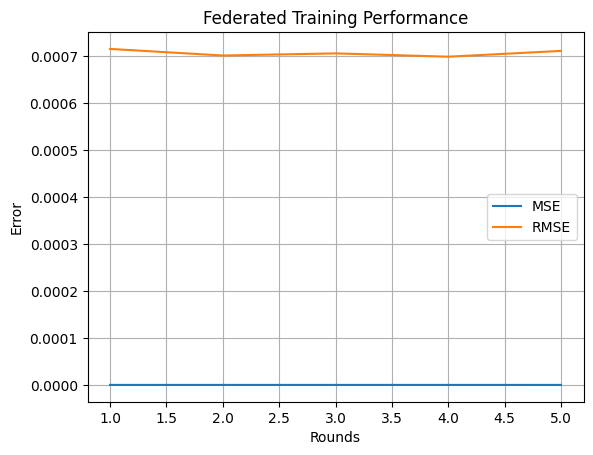

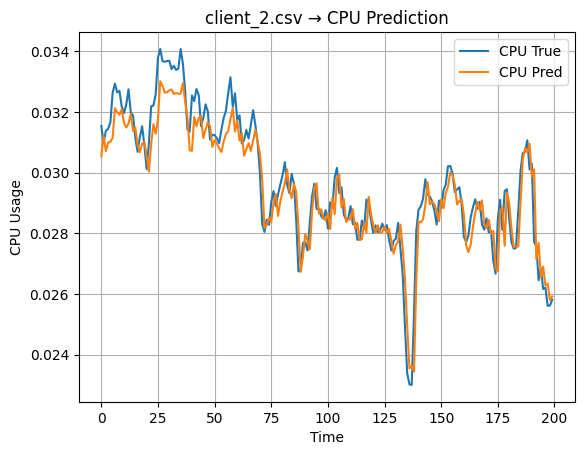

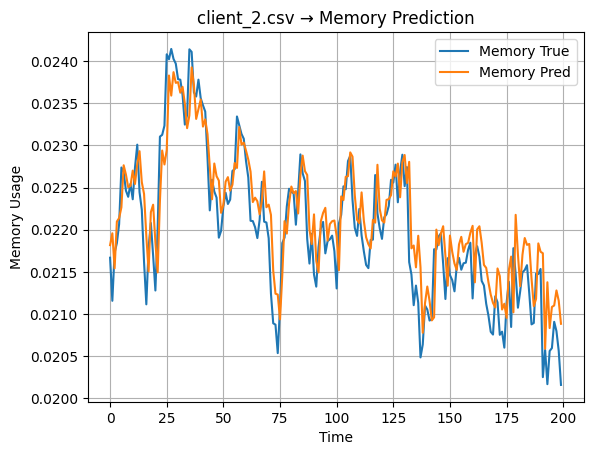

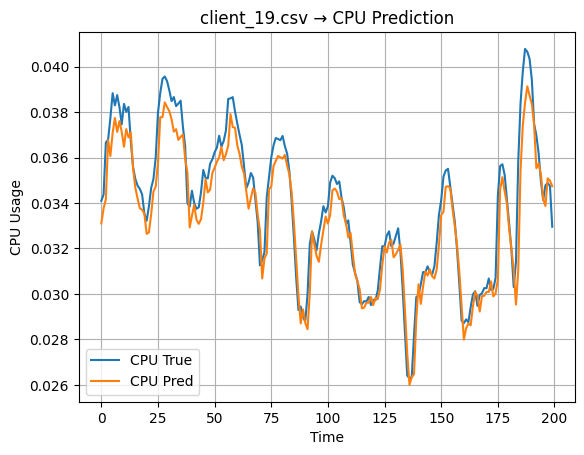

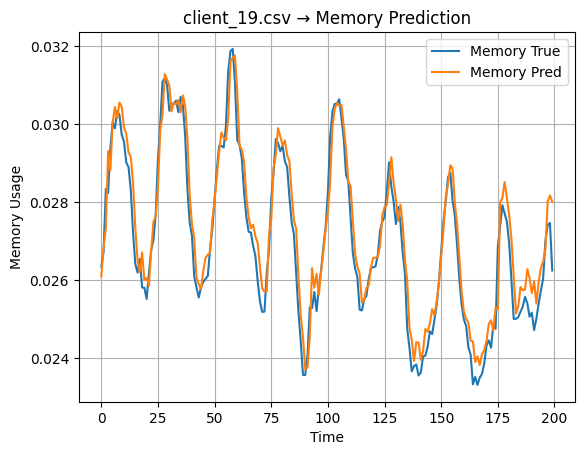

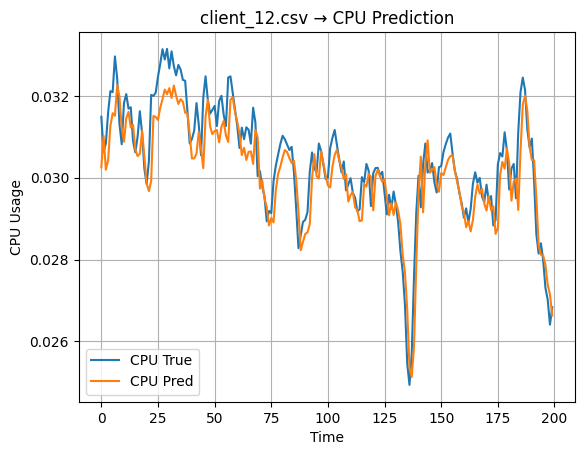

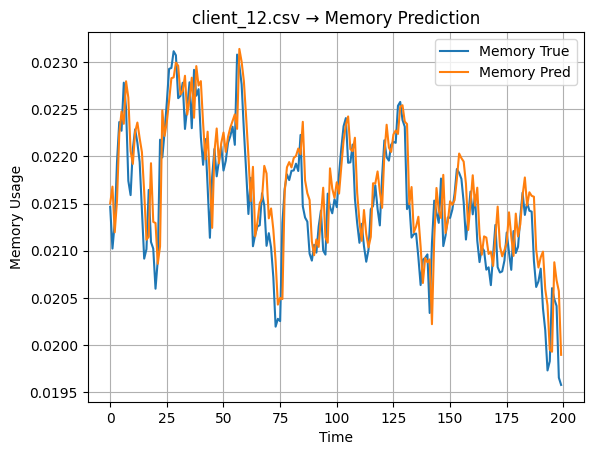

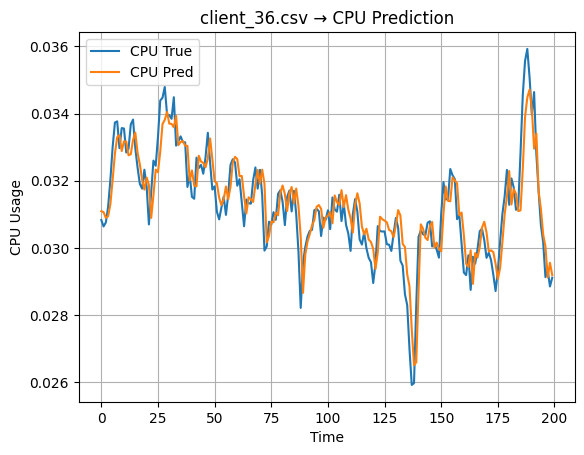

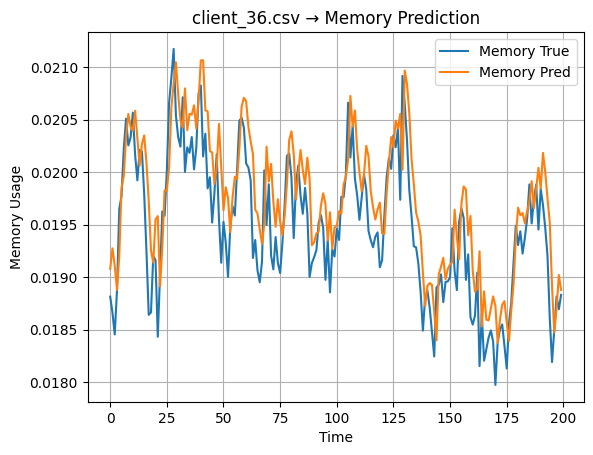

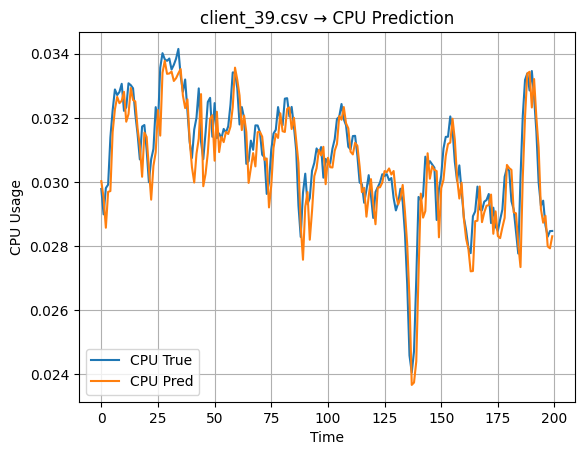

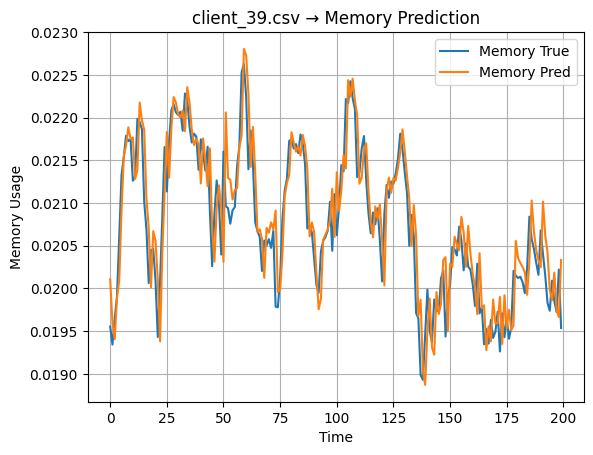

In [13]:
rounds = range(1, len(mse_list) + 1)

plt.figure()
plt.plot(rounds, mse_list, label="MSE")
plt.plot(rounds, rmse_list, label="RMSE")

plt.xlabel("Rounds")
plt.ylabel("Error")
plt.title("Federated Training Performance")
plt.legend()
plt.grid()

plt.show()
for client, data in client_preds.items():

    y_true = data["y_true"]
    y_pred = data["y_pred"]

    # CPU
    plt.figure()
    plt.plot(y_true[:200, 0], label="CPU True")
    plt.plot(y_pred[:200, 0], label="CPU Pred")

    plt.title(f"{client} → CPU Prediction")
    plt.xlabel("Time")
    plt.ylabel("CPU Usage")
    plt.legend()
    plt.grid()
    plt.show()

    # MEMORY
    plt.figure()
    plt.plot(y_true[:200, 1], label="Memory True")
    plt.plot(y_pred[:200, 1], label="Memory Pred")

    plt.title(f"{client} → Memory Prediction")
    plt.xlabel("Time")
    plt.ylabel("Memory Usage")
    plt.legend()
    plt.grid()
    plt.show()
